In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("../data/Resumes_dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df.columns

Index(['Candidate_ID', 'Job_Role', 'Experience_Level', 'Experience_Years',
       'Education', 'Skills', 'Technical_Skills', 'Soft_Skills',
       'Certifications', 'Projects', 'Previous_Job_Title', 'Industry',
       'Resume_Summary', 'Resume_Text', 'Target_Job_Title', 'Job_Description',
       'Required_Skills', 'Preferred_Skills', 'Matched_Skills',
       'Missing_Skills', 'Skill_Match_Percentage', 'ATS_Score',
       'Recommendation', 'Recommendation_Reason'],
      dtype='str')

In [4]:
df.shape

(4000, 24)

In [5]:
df.head()

,Candidate_ID,Job_Role,Experience_Level,Experience_Years,Education,Skills,Technical_Skills,Soft_Skills,Certifications,Projects,...,Target_Job_Title,Job_Description,Required_Skills,Preferred_Skills,Matched_Skills,Missing_Skills,Skill_Match_Percentage,ATS_Score,Recommendation,Recommendation_Reason
0,C0001,Backend Developer,Fresher,0,B.Tech Information Technology,"REST APIs, Express, Docker, Java, PostgreSQL, Git","REST APIs, Express, Docker, Java","Time Management, Teamwork, Analytical Thinking",NaN,Prediction project for Backend Developer using...,...,Backend Developer,"We are hiring a Backend Developer to design, d...","MongoDB, Python, Docker, Redis, Java, PostgreSQL","Git, Express, REST APIs","Docker, Java, PostgreSQL","MongoDB, Python, Redis",50.00,29.49,Not Recommended,Matched 3 of 6 required skills; missing MongoD...
1,C0002,Backend Developer,Fresher,0,M.Sc Computer Science,"Java, Git, MongoDB, Python, Node.js, PostgreSQ...","Java, Git, MongoDB, Python, Node.js","Analytical Thinking, Collaboration, Communication",Kubernetes certification,Analytics project for Backend Developer using ...,...,Backend Developer,"We are hiring a Backend Developer to design, d...","Redis, Docker, Java, Express, Python, REST APIs","Node.js, Git, MongoDB","Java, Python, REST APIs","Redis, Docker, Express",50.00,38.08,Not Recommended,"Matched 3 of 6 required skills; missing Redis,..."
2,C0003,Backend Developer,Fresher,0,B.Tech Information Technology,"Node.js, PostgreSQL, Docker, Java, Redis, Git,...","Node.js, PostgreSQL, Docker, Java, Redis","Collaboration, Time Management, Communication",Kubernetes certification,Management project for Backend Developer using...,...,Backend Developer,"We are hiring a Backend Developer to design, d...","Node.js, Docker, Express, Java, Redis, PostgreSQL","Git, REST APIs, Python","Node.js, Docker, Java, Redis, PostgreSQL",Express,83.33,58.71,Consider,Matched 5 of 6 required skills; missing Expres...
3,C0004,Backend Developer,Fresher,0,B.Tech Computer Science,"Express, Redis, MongoDB, PostgreSQL, Git, Java...","Express, Redis, MongoDB, PostgreSQL, Git, Java","Problem Solving, Time Management, Collaboration",NaN,E-commerce project for Backend Developer using...,...,Backend Developer,"We are hiring a Backend Developer to design, d...","MongoDB, Git, PostgreSQL, Java, Docker, REST APIs","Redis, Express, Node.js","MongoDB, Git, PostgreSQL, Java","Docker, REST APIs",66.67,47.13,Not Recommended,Matched 4 of 6 required skills; missing Docker...
4,C0005,Backend Developer,Fresher,0,B.E Information Technology,"Java, Docker, REST APIs, MongoDB, PostgreSQL","Java, Docker, REST APIs","Teamwork, Time Management, Collaboration",NaN,Prediction project for Backend Developer using...,...,Backend Developer,"We are hiring a Backend Developer to design, d...","Node.js, Redis, Python, PostgreSQL, MongoDB, Git","REST APIs, Java, Docker","PostgreSQL, MongoDB","Node.js, Redis, Python, Git",33.33,24.91,Not Recommended,Matched 2 of 6 required skills; missing Node.j...


In [6]:
required_columns = [
    "Job_Role",
    "Experience_Level",
    "Experience_Years",
    "Education",
    "Skills",
    "Technical_Skills",
    "Projects",
    "Target_Job_Title",
    "Job_Description",
    "Required_Skills",
    "Preferred_Skills"
]

for col in required_columns:
    if col in df.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ Missing: {col}")

✓ Job_Role
✓ Experience_Level
✓ Experience_Years
✓ Education
✓ Skills
✓ Technical_Skills
✓ Projects
✓ Target_Job_Title
✓ Job_Description
✓ Required_Skills
✓ Preferred_Skills


In [7]:
print(df[required_columns].isnull().sum())

Job_Role            0
Experience_Level    0
Experience_Years    0
Education           0
Skills              0
Technical_Skills    0
Projects            0
Target_Job_Title    0
Job_Description     0
Required_Skills     0
Preferred_Skills    0
dtype: int64


In [8]:
sample = df.iloc[0]

for col in required_columns:
    print(f"\n{col}:")
    print(sample[col])


Job_Role:
Backend Developer

Experience_Level:
Fresher

Experience_Years:
0

Education:
B.Tech Information Technology

Skills:
REST APIs, Express, Docker, Java, PostgreSQL, Git

Technical_Skills:
REST APIs, Express, Docker, Java

Projects:
Prediction project for Backend Developer using REST APIs, Express, Docker

Target_Job_Title:
Backend Developer

Job_Description:
We are hiring a Backend Developer to design, develop, test and maintain technology solutions. Required skills include MongoDB, Python, Docker, Redis, Java, PostgreSQL. Candidates should demonstrate relevant education, practical projects and appropriate experience. Preferred skills include Node.js, Git.

Required_Skills:
MongoDB, Python, Docker, Redis, Java, PostgreSQL

Preferred_Skills:
Git, Express, REST APIs


In [9]:
import re

def normalize_skill(skill):
    """
    Normalize an individual skill.
    """

    skill = str(skill).strip().lower()

    # Replace common variations
    replacements = {
        "node": "node.js",
        "node js": "node.js",
        "nodejs": "node.js",

        "reactjs": "react",
        "react.js": "react",

        "vuejs": "vue",
        "vue.js": "vue",

        "angularjs": "angular",
        "angular.js": "angular",

        "postgres": "postgresql",

        "scikit learn": "scikit-learn",
        "sklearn": "scikit-learn",

        "powerbi": "power bi",

        "ms sql": "sql server",
        "mssql": "sql server",

        "amazon web services": "aws",
        "microsoft azure": "azure",
        "google cloud platform": "gcp"
    }

    if skill in replacements:
        skill = replacements[skill]

    return skill

In [10]:
def parse_skills(skill_string):
    """
    Convert comma-separated skills into a normalized set.
    """

    if pd.isna(skill_string):
        return set()

    skills = str(skill_string).split(",")

    normalized = set()

    for skill in skills:
        skill = normalize_skill(skill)

        if skill:
            normalized.add(skill)

    return normalized

In [11]:
test_skills = "Python, SQL, Node.js, Docker, Git, React"

print(parse_skills(test_skills))

{'docker', 'python', 'node.js', 'react', 'git', 'sql'}


In [12]:
def calculate_skill_match(candidate_skills, required_skills):

    candidate = parse_skills(candidate_skills)
    required = parse_skills(required_skills)

    matched = candidate.intersection(required)
    missing = required.difference(candidate)

    if len(required) == 0:
        match_percentage = 0.0
    else:
        match_percentage = (len(matched) / len(required)) * 100

    return {
        "matched_skills": sorted(matched),
        "missing_skills": sorted(missing),
        "skill_match_percentage": round(match_percentage, 2)
    }

In [13]:
candidate = df.iloc[0]

result = calculate_skill_match(
    candidate["Skills"],
    candidate["Required_Skills"]
)

print("Candidate:", candidate["Candidate_ID"])
print("Job Role:", candidate["Job_Role"])

print("\nCandidate Skills:")
print(candidate["Skills"])

print("\nRequired Skills:")
print(candidate["Required_Skills"])

print("\nMatched Skills:")
print(result["matched_skills"])

print("\nMissing Skills:")
print(result["missing_skills"])

print("\nSkill Match Percentage:")
print(result["skill_match_percentage"])

Candidate: C0001
Job Role: Backend Developer

Candidate Skills:
REST APIs, Express, Docker, Java, PostgreSQL, Git

Required Skills:
MongoDB, Python, Docker, Redis, Java, PostgreSQL

Matched Skills:
['docker', 'java', 'postgresql']

Missing Skills:
['mongodb', 'python', 'redis']

Skill Match Percentage:
50.0


In [14]:
results = []

for _, row in df.iterrows():

    result = calculate_skill_match(
        row["Skills"],
        row["Required_Skills"]
    )

    results.append(result)

df["Model2_Matched_Skills"] = [
    ", ".join(r["matched_skills"])
    for r in results
]

df["Model2_Missing_Skills"] = [
    ", ".join(r["missing_skills"])
    for r in results
]

df["Model2_Skill_Match_Percentage"] = [
    r["skill_match_percentage"]
    for r in results
]

print("Model 2 skill matching completed!")

display(
    df[
        [
            "Candidate_ID",
            "Job_Role",
            "Skills",
            "Required_Skills",
            "Model2_Matched_Skills",
            "Model2_Missing_Skills",
            "Model2_Skill_Match_Percentage"
        ]
    ].head(10)
)

Model 2 skill matching completed!


,Candidate_ID,Job_Role,Skills,Required_Skills,Model2_Matched_Skills,Model2_Missing_Skills,Model2_Skill_Match_Percentage
0,C0001,Backend Developer,"REST APIs, Express, Docker, Java, PostgreSQL, Git","MongoDB, Python, Docker, Redis, Java, PostgreSQL","docker, java, postgresql","mongodb, python, redis",50.00
1,C0002,Backend Developer,"Java, Git, MongoDB, Python, Node.js, PostgreSQ...","Redis, Docker, Java, Express, Python, REST APIs","java, python, rest apis","docker, express, redis",50.00
2,C0003,Backend Developer,"Node.js, PostgreSQL, Docker, Java, Redis, Git,...","Node.js, Docker, Express, Java, Redis, PostgreSQL","docker, java, node.js, postgresql, redis",express,83.33
3,C0004,Backend Developer,"Express, Redis, MongoDB, PostgreSQL, Git, Java...","MongoDB, Git, PostgreSQL, Java, Docker, REST APIs","git, java, mongodb, postgresql","docker, rest apis",66.67
4,C0005,Backend Developer,"Java, Docker, REST APIs, MongoDB, PostgreSQL","Node.js, Redis, Python, PostgreSQL, MongoDB, Git","mongodb, postgresql","git, node.js, python, redis",33.33
5,C0006,Backend Developer,"PostgreSQL, REST APIs, Express, Python, Java","Java, Git, Redis, MongoDB, Python, REST APIs","java, python, rest apis","git, mongodb, redis",50.00
6,C0007,Backend Developer,"Redis, Docker, Git, Python, Java, PostgreSQL, ...","Express, Python, Java, PostgreSQL, MongoDB, Do...","docker, java, mongodb, postgresql, python",express,83.33
7,C0008,Backend Developer,"Express, Java, Docker, PostgreSQL, Git, Node.j...","Python, Java, Git, Express, PostgreSQL, Node.js","express, git, java, node.js, postgresql",python,83.33
8,C0009,Backend Developer,"Docker, Java, Python, PostgreSQL, REST APIs, R...","Express, MongoDB, Python, Java, Git, Redis","express, git, java, mongodb, python, redis",,100.00
9,C0010,Backend Developer,"Python, Git, Redis, REST APIs, MongoDB, Java, ...","Java, Node.js, Git, REST APIs, Python, Redis","git, java, python, redis, rest apis",node.js,83.33


In [15]:
def calculate_preferred_skill_match(candidate_skills, preferred_skills):

    candidate = parse_skills(candidate_skills)
    preferred = parse_skills(preferred_skills)

    if len(preferred) == 0:
        return {
            "matched_preferred_skills": [],
            "preferred_match_percentage": 0.0
        }

    matched = candidate.intersection(preferred)

    percentage = (len(matched) / len(preferred)) * 100

    return {
        "matched_preferred_skills": sorted(matched),
        "preferred_match_percentage": round(percentage, 2)
    }

In [16]:
candidate = df.iloc[0]

preferred_result = calculate_preferred_skill_match(
    candidate["Skills"],
    candidate["Preferred_Skills"]
)

print("Candidate:", candidate["Candidate_ID"])

print("\nPreferred Skills:")
print(candidate["Preferred_Skills"])

print("\nMatched Preferred Skills:")
print(preferred_result["matched_preferred_skills"])

print("\nPreferred Skill Match:")
print(preferred_result["preferred_match_percentage"], "%")

Candidate: C0001

Preferred Skills:
Git, Express, REST APIs

Matched Preferred Skills:
['express', 'git', 'rest apis']

Preferred Skill Match:
100.0 %


In [17]:
def calculate_experience_score(experience_level, experience_years):

    experience_years = float(experience_years)

    if experience_level == "Fresher":

        if experience_years <= 1:
            return 100
        else:
            return 90

    elif experience_level == "Junior":

        if experience_years >= 1:
            return 100
        elif experience_years >= 0.5:
            return 80
        else:
            return 60

    elif experience_level == "Mid-level":

        if experience_years >= 3:
            return 100
        elif experience_years >= 2:
            return 80
        elif experience_years >= 1:
            return 60
        else:
            return 40

    elif experience_level == "Senior":

        if experience_years >= 6:
            return 100
        elif experience_years >= 4:
            return 80
        elif experience_years >= 2:
            return 60
        else:
            return 40

    return 50

In [18]:
print(calculate_experience_score("Fresher", 0))
print(calculate_experience_score("Junior", 2))
print(calculate_experience_score("Mid-level", 4))
print(calculate_experience_score("Senior", 8))

100
100
100
100


In [19]:
IT_EDUCATION_KEYWORDS = [
    "computer science",
    "information technology",
    "computer applications",
    "software engineering",
    "data science",
    "artificial intelligence",
    "information systems"
]

def calculate_education_score(education):

    education = str(education).lower()

    for keyword in IT_EDUCATION_KEYWORDS:

        if keyword in education:
            return 100

    return 60

In [20]:
def calculate_project_match(projects, required_skills):

    project_text = str(projects).lower()

    required = parse_skills(required_skills)

    if len(required) == 0:
        return 0.0

    matched = []

    for skill in required:

        if skill in project_text:
            matched.append(skill)

    score = (len(matched) / len(required)) * 100

    return round(score, 2)

In [21]:
def calculate_job_match_score(
    skill_match,
    experience_match,
    project_match,
    preferred_match,
    education_match
):

    # Base weighted score
    score = (
        skill_match * 0.50 +
        experience_match * 0.20 +
        project_match * 0.15 +
        preferred_match * 0.10 +
        education_match * 0.05
    )

    # Required-skill gates
    if skill_match < 20:
        score = min(score, 35)

    elif skill_match < 40:
        score = min(score, 50)

    elif skill_match < 60:
        score = min(score, 70)

    return round(score, 2)

In [22]:
candidate = df.iloc[0]

skill_result = calculate_skill_match(
    candidate["Skills"],
    candidate["Required_Skills"]
)

preferred_result = calculate_preferred_skill_match(
    candidate["Skills"],
    candidate["Preferred_Skills"]
)

experience_score = calculate_experience_score(
    candidate["Experience_Level"],
    candidate["Experience_Years"]
)

education_score = calculate_education_score(
    candidate["Education"]
)

project_score = calculate_project_match(
    candidate["Projects"],
    candidate["Required_Skills"]
)

final_score = calculate_job_match_score(
    skill_result["skill_match_percentage"],
    experience_score,
    project_score,
    preferred_result["preferred_match_percentage"],
    education_score
)

print("Candidate:", candidate["Candidate_ID"])
print("Job Role:", candidate["Job_Role"])

print("\nRequired Skill Match:",
      skill_result["skill_match_percentage"], "%")

print("Preferred Skill Match:",
      preferred_result["preferred_match_percentage"], "%")

print("Experience Score:",
      experience_score)

print("Project Match:",
      project_score, "%")

print("Education Score:",
      education_score)

print("\nFINAL JOB MATCH SCORE:",
      final_score, "%")

Candidate: C0001
Job Role: Backend Developer

Required Skill Match: 50.0 %
Preferred Skill Match: 100.0 %
Experience Score: 100
Project Match: 16.67 %
Education Score: 100

FINAL JOB MATCH SCORE: 62.5 %


In [23]:
def calculate_model2(row):

    # Required skill matching
    skill_result = calculate_skill_match(
        row["Skills"],
        row["Required_Skills"]
    )

    # Preferred skill matching
    preferred_result = calculate_preferred_skill_match(
        row["Skills"],
        row["Preferred_Skills"]
    )

    # Experience
    experience_score = calculate_experience_score(
        row["Experience_Level"],
        row["Experience_Years"]
    )

    # Education
    education_score = calculate_education_score(
        row["Education"]
    )

    # Project
    project_score = calculate_project_match(
        row["Projects"],
        row["Required_Skills"]
    )

    # Final score
    final_score = calculate_job_match_score(
        skill_result["skill_match_percentage"],
        experience_score,
        project_score,
        preferred_result["preferred_match_percentage"],
        education_score
    )

    return pd.Series({
        "Model2_Matched_Skills":
            ", ".join(skill_result["matched_skills"]),

        "Model2_Missing_Skills":
            ", ".join(skill_result["missing_skills"]),

        "Model2_Skill_Match_Percentage":
            skill_result["skill_match_percentage"],

        "Model2_Preferred_Matched_Skills":
            ", ".join(preferred_result["matched_preferred_skills"]),

        "Model2_Preferred_Match_Percentage":
            preferred_result["preferred_match_percentage"],

        "Model2_Experience_Score":
            experience_score,

        "Model2_Project_Match":
            project_score,

        "Model2_Education_Score":
            education_score,

        "Model2_Job_Match_Score":
            final_score
    })


model2_results = df.apply(calculate_model2, axis=1)

df = pd.concat([df, model2_results], axis=1)

print("Model 2 completed for", len(df), "candidates.")

display(
    df[
        [
            "Candidate_ID",
            "Job_Role",
            "Model2_Skill_Match_Percentage",
            "Model2_Job_Match_Score"
        ]
    ].head(10)
)

Model 2 completed for 4000 candidates.


,Candidate_ID,Job_Role,Model2_Skill_Match_Percentage,Model2_Skill_Match_Percentage,Model2_Job_Match_Score
0,C0001,Backend Developer,50.00,50.00,62.50
1,C0002,Backend Developer,50.00,50.00,62.50
2,C0003,Backend Developer,83.33,83.33,80.83
3,C0004,Backend Developer,66.67,66.67,70.84
4,C0005,Backend Developer,33.33,33.33,50.00
5,C0006,Backend Developer,50.00,50.00,59.17
6,C0007,Backend Developer,83.33,83.33,73.83
7,C0008,Backend Developer,83.33,83.33,81.66
8,C0009,Backend Developer,100.00,100.00,86.67
9,C0010,Backend Developer,83.33,83.33,77.50


In [24]:
df = pd.read_csv("../data/Resumes_dataset.csv")

model2_results = df.apply(calculate_model2, axis=1)

df = pd.concat([df, model2_results], axis=1)

print(df.shape)

(4000, 33)


In [25]:
print("Model 2 Job Match Score Statistics")
print("=" * 45)

print(df["Model2_Job_Match_Score"].describe())

Model 2 Job Match Score Statistics
count    4000.000000
mean       64.570667
std        13.546096
min        23.000000
25%        59.170000
50%        67.170000
75%        73.830000
max        92.500000
Name: Model2_Job_Match_Score, dtype: float64


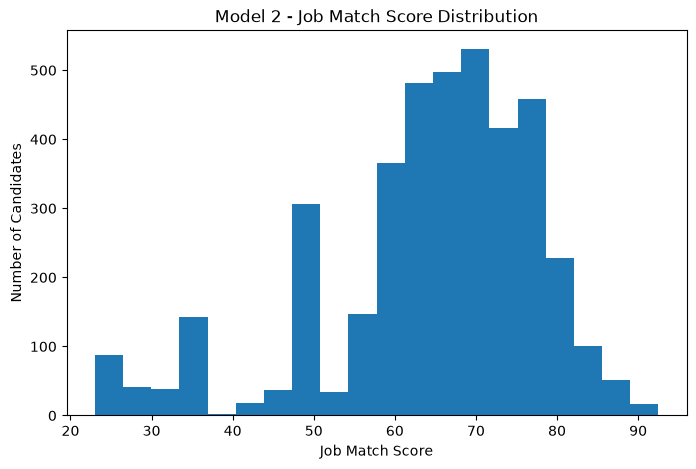

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df["Model2_Job_Match_Score"],
    bins=20
)

plt.xlabel("Job Match Score")
plt.ylabel("Number of Candidates")
plt.title("Model 2 - Job Match Score Distribution")

plt.show()

In [27]:
role_scores = (
    df.groupby("Job_Role")["Model2_Job_Match_Score"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(role_scores)

,count,mean,min,max
Job_Role,,,,
Python Developer,200,67.13920,34.67,90.83
Data Scientist,200,66.26830,33.84,89.17
Machine Learning Engineer,200,66.12340,28.83,85.83
Frontend Developer,200,65.98825,23.00,88.33
Data Analyst,200,65.91780,25.00,89.17
Full Stack Developer,200,65.85155,34.67,89.17
Backend Developer,200,65.31010,28.33,86.67
Data Engineer,200,65.29105,23.00,89.17
QA Engineer,200,65.21865,25.00,92.50


In [28]:
experience_scores = (
    df.groupby("Experience_Level")["Model2_Job_Match_Score"]
    .agg(["count", "mean", "min", "max"])
)

display(experience_scores)

,count,mean,min,max
Experience_Level,,,,
Fresher,1000,64.63774,23.0,92.50
Junior,1000,63.84183,23.0,89.17
Mid-level,1000,64.70875,23.0,89.17
Senior,1000,65.09435,23.0,90.83


In [29]:
top20 = df.sort_values(
    "Model2_Job_Match_Score",
    ascending=False
).head(20)

display(
    top20[
        [
            "Candidate_ID",
            "Job_Role",
            "Experience_Level",
            "Skills",
            "Model2_Matched_Skills",
            "Model2_Missing_Skills",
            "Model2_Skill_Match_Percentage",
            "Model2_Experience_Score",
            "Model2_Project_Match",
            "Model2_Preferred_Match_Percentage",
            "Model2_Education_Score",
            "Model2_Job_Match_Score"
        ]
    ]
)

,Candidate_ID,Job_Role,Experience_Level,Skills,Model2_Matched_Skills,Model2_Missing_Skills,Model2_Skill_Match_Percentage,Model2_Experience_Score,Model2_Project_Match,Model2_Preferred_Match_Percentage,Model2_Education_Score,Model2_Job_Match_Score
1633,C1634,QA Engineer,Fresher,"Selenium, Python, Test Automation, API Testing...","api testing, git, postman, python, selenium, t...",,100.0,100,50.00,100.00,100,92.50
2161,C2162,Python Developer,Senior,"FastAPI, Git, PostgreSQL, Django, Python, SQL,...","fastapi, flask, git, postgresql, python, sql",,100.0,100,83.33,33.33,100,90.83
1105,C1106,Data Analyst,Mid-level,"Statistics, Excel, NumPy, Pandas, SQL, Tableau...","data visualization, etl, excel, numpy, sql, st...",,100.0,100,50.00,66.67,100,89.17
652,C0653,Data Scientist,Junior,"Jupyter, SQL, Scikit-learn, Seaborn, Machine L...","jupyter, machine learning, matplotlib, numpy, ...",,100.0,100,50.00,66.67,100,89.17
3816,C3817,AI Engineer,Fresher,"NLP, Deep Learning, TensorFlow, Python, Vector...","deep learning, machine learning, nlp, python, ...",,100.0,100,50.00,66.67,100,89.17
1102,C1103,Data Analyst,Mid-level,"Tableau, Python, Data Visualization, Statistic...","data visualization, etl, pandas, python, stati...",,100.0,100,50.00,66.67,100,89.17
2150,C2151,Python Developer,Senior,"Docker, Django, FastAPI, Git, PostgreSQL, Pyth...","django, docker, fastapi, git, rest apis, sql",,100.0,100,50.00,66.67,100,89.17
1345,C1346,DevOps Engineer,Mid-level,"Docker, Terraform, Prometheus, Git, CI/CD, Jen...","aws, ci/cd, docker, kubernetes, prometheus, te...",,100.0,100,50.00,66.67,100,89.17
2705,C2706,Software Engineer,Mid-level,"SQL, Data Structures, Algorithms, Java, Testin...","algorithms, data structures, git, java, python...",,100.0,100,50.00,66.67,100,89.17
1424,C1425,Cybersecurity Analyst,Fresher,"Wireshark, Network Security, Incident Response...","cryptography, incident response, network secur...",,100.0,100,50.00,66.67,100,89.17


In [30]:
bottom10 = df.sort_values(
    "Model2_Job_Match_Score",
    ascending=True
).head(10)

display(
    bottom10[
        [
            "Candidate_ID",
            "Job_Role",
            "Experience_Level",
            "Skills",
            "Model2_Matched_Skills",
            "Model2_Missing_Skills",
            "Model2_Skill_Match_Percentage",
            "Model2_Job_Match_Score"
        ]
    ]
)

,Candidate_ID,Job_Role,Experience_Level,Skills,Model2_Matched_Skills,Model2_Missing_Skills,Model2_Skill_Match_Percentage,Model2_Job_Match_Score
2702,C2703,Software Engineer,Mid-level,"Testing, Python, Java, C++, Docker",,"css, html, mongodb, node.js, rest apis, sql",0.0,23.0
3271,C3272,System Administrator,Junior,"Networking, Active Directory, VMware, PowerShe...",,"dns, firewalls, network security, routing, tcp...",0.0,23.0
475,C0476,Frontend Developer,Junior,"Next.js, Git, CSS, HTML, Tailwind CSS",,"accessibility, adobe xd, figma, prototyping, u...",0.0,23.0
400,C0401,Frontend Developer,Fresher,"Redux, Tailwind CSS, Next.js, JavaScript, Type...",,"accessibility, interaction design, prototyping...",0.0,23.0
420,C0421,Frontend Developer,Fresher,"Redux, React, HTML, TypeScript, CSS, Next.js, ...",,"adobe xd, design systems, figma, interaction d...",0.0,23.0
3483,C3484,UI/UX Designer,Junior,"Visual Design, Interaction Design, Accessibili...",,"git, html, mongodb, node.js, react, rest apis",0.0,23.0
3473,C3474,UI/UX Designer,Junior,"Accessibility, Figma, Adobe XD, User Research,...",,"css, git, html, javascript, next.js, react",0.0,23.0
3412,C3413,UI/UX Designer,Fresher,"User Research, Interaction Design, Visual Desi...",,"css, javascript, mongodb, node.js, react, sql",0.0,23.0
3314,C3315,System Administrator,Mid-level,"Monitoring, PowerShell, Windows Server, Networ...",,"aws, ci/cd, docker, jenkins, prometheus, python",0.0,23.0
2393,C2394,Mobile App Developer,Senior,"Flutter, SQLite, Android, Dart, Kotlin",,"css, html, javascript, next.js, redux, typescript",0.0,23.0


In [31]:
candidate = df[df["Candidate_ID"] == "C3763"].iloc[0]

print("Candidate ID:", candidate["Candidate_ID"])
print("Actual Role:", candidate["Job_Role"])
print("Target Job:", candidate["Target_Job_Title"])

print("\nCandidate Skills:")
print(candidate["Skills"])

print("\nRequired Skills:")
print(candidate["Required_Skills"])

print("\nMatched Skills:")
print(candidate["Model2_Matched_Skills"])

print("\nMissing Skills:")
print(candidate["Model2_Missing_Skills"])

print("\nSkill Match:")
print(candidate["Model2_Skill_Match_Percentage"])

print("\nFinal Match:")
print(candidate["Model2_Job_Match_Score"])

Candidate ID: C3763
Actual Role: Data Engineer
Target Job: Database Administrator

Candidate Skills:
Python, Kafka, AWS, Docker, PySpark, Apache Spark, ETL

Required Skills:
Linux, PL/SQL, PostgreSQL, Oracle, Database Design, SQL

Matched Skills:


Missing Skills:
database design, linux, oracle, pl/sql, postgresql, sql

Skill Match:
0.0

Final Match:
23.0


In [32]:
print("Total candidates:", len(df))

cross_role = df[
    df["Job_Role"].str.lower() !=
    df["Target_Job_Title"].str.lower()
]

print("Cross-role candidates:", len(cross_role))

print(
    "Cross-role percentage:",
    round(len(cross_role) / len(df) * 100, 2),
    "%"
)

Total candidates: 4000
Cross-role candidates: 472
Cross-role percentage: 11.8 %


In [33]:
display(
    cross_role[
        [
            "Candidate_ID",
            "Job_Role",
            "Target_Job_Title",
            "Skills",
            "Required_Skills",
            "Model2_Skill_Match_Percentage"
        ]
    ].head(20)
)

,Candidate_ID,Job_Role,Target_Job_Title,Skills,Required_Skills,Model2_Skill_Match_Percentage
14,C0015,Backend Developer,Python Developer,"Git, REST APIs, Python, Redis, Docker, Express...","Pytest, Docker, Django, FastAPI, REST APIs, Git",50.00
18,C0019,Backend Developer,Python Developer,"REST APIs, PostgreSQL, Docker, Git, Python, Ja...","FastAPI, Django, PostgreSQL, Pytest, Flask, RE...",50.00
37,C0038,Backend Developer,Python Developer,"MongoDB, Node.js, Express, Java, REST APIs, Do...","REST APIs, Git, Pytest, SQL, Flask, Python",16.67
41,C0042,Backend Developer,Python Developer,"Node.js, MongoDB, Java, PostgreSQL, Python","SQL, Docker, Django, FastAPI, REST APIs, Git",0.00
52,C0053,Backend Developer,Full Stack Developer,"PostgreSQL, Node.js, MongoDB, Java, Redis, SQL","HTML, MongoDB, Express, SQL, REST APIs, CSS",33.33
65,C0066,Backend Developer,Python Developer,"Git, Java, Node.js, Python, Express, Redis, RE...","SQL, Flask, FastAPI, REST APIs, PostgreSQL, Git",33.33
71,C0072,Backend Developer,Full Stack Developer,"Node.js, Redis, PostgreSQL, Java, Python, Git","SQL, Node.js, Express, JavaScript, REST APIs, Git",33.33
73,C0074,Backend Developer,Full Stack Developer,"Java, Docker, Redis, MongoDB, Python, Express,...","Git, HTML, SQL, Express, JavaScript, REST APIs",33.33
75,C0076,Backend Developer,Python Developer,"Express, Git, Java, Python, REST APIs, React","Python, PostgreSQL, Git, Django, REST APIs, Do...",50.00
76,C0077,Backend Developer,Full Stack Developer,"Docker, Redis, Python, Node.js, PostgreSQL, Ex...","JavaScript, Node.js, MongoDB, CSS, REST APIs, ...",50.00


In [34]:
bottom20 = df.sort_values(
    "Model2_Job_Match_Score",
    ascending=True
).head(20)

display(
    bottom20[
        [
            "Candidate_ID",
            "Job_Role",
            "Target_Job_Title",
            "Model2_Matched_Skills",
            "Model2_Missing_Skills",
            "Model2_Skill_Match_Percentage",
            "Model2_Job_Match_Score"
        ]
    ]
)

,Candidate_ID,Job_Role,Target_Job_Title,Model2_Matched_Skills,Model2_Missing_Skills,Model2_Skill_Match_Percentage,Model2_Job_Match_Score
2702,C2703,Software Engineer,Full Stack Developer,,"css, html, mongodb, node.js, rest apis, sql",0.0,23.0
3271,C3272,System Administrator,Network Engineer,,"dns, firewalls, network security, routing, tcp...",0.0,23.0
475,C0476,Frontend Developer,UI/UX Designer,,"accessibility, adobe xd, figma, prototyping, u...",0.0,23.0
400,C0401,Frontend Developer,UI/UX Designer,,"accessibility, interaction design, prototyping...",0.0,23.0
420,C0421,Frontend Developer,UI/UX Designer,,"adobe xd, design systems, figma, interaction d...",0.0,23.0
3483,C3484,UI/UX Designer,Full Stack Developer,,"git, html, mongodb, node.js, react, rest apis",0.0,23.0
3473,C3474,UI/UX Designer,Frontend Developer,,"css, git, html, javascript, next.js, react",0.0,23.0
3412,C3413,UI/UX Designer,Full Stack Developer,,"css, javascript, mongodb, node.js, react, sql",0.0,23.0
3314,C3315,System Administrator,DevOps Engineer,,"aws, ci/cd, docker, jenkins, prometheus, python",0.0,23.0
2393,C2394,Mobile App Developer,Frontend Developer,,"css, html, javascript, next.js, redux, typescript",0.0,23.0


In [35]:
def job_match(
    candidate_skills,
    required_skills,
    preferred_skills,
    experience_level,
    experience_years,
    education,
    projects
):
    
    # ------------------------------------------------
    # 1. REQUIRED SKILL MATCH
    # ------------------------------------------------
    
    candidate_skill_set = set(
        parse_skills(candidate_skills)
    )
    
    required_skill_set = set(
        parse_skills(required_skills)
    )
    
    preferred_skill_set = set(
        parse_skills(preferred_skills)
    )
    
    matched_skills = sorted(
        candidate_skill_set.intersection(required_skill_set)
    )
    
    missing_skills = sorted(
        required_skill_set - candidate_skill_set
    )
    
    if len(required_skill_set) > 0:
        skill_match_percentage = (
            len(matched_skills) /
            len(required_skill_set)
        ) * 100
    else:
        skill_match_percentage = 0
    
    
    # ------------------------------------------------
    # 2. PREFERRED SKILL MATCH
    # ------------------------------------------------
    
    matched_preferred_skills = sorted(
        candidate_skill_set.intersection(preferred_skill_set)
    )
    
    if len(preferred_skill_set) > 0:
        preferred_match_percentage = (
            len(matched_preferred_skills) /
            len(preferred_skill_set)
        ) * 100
    else:
        preferred_match_percentage = 0
    
    
    # ------------------------------------------------
    # 3. EXPERIENCE SCORE
    # ------------------------------------------------
    
    experience_score = calculate_experience_score(
        experience_level,
        experience_years
    )
    
    
    # ------------------------------------------------
    # 4. PROJECT MATCH
    # ------------------------------------------------
    
    project_match = calculate_project_match(
        projects,
        required_skills
    )
    
    
    # ------------------------------------------------
    # 5. EDUCATION SCORE
    # ------------------------------------------------
    
    education_score = calculate_education_score(
        education
    )
    
    
    # ------------------------------------------------
    # 6. FINAL JOB MATCH SCORE
    # ------------------------------------------------
    
    final_score = calculate_job_match_score(
        skill_match_percentage,
        experience_score,
        project_match,
        preferred_match_percentage,
        education_score
    )
    
    
    # ------------------------------------------------
    # 7. RETURN RESULT
    # ------------------------------------------------
    
    return {
        "matched_skills": matched_skills,
        "missing_skills": missing_skills,
        "skill_match_percentage": round(
            skill_match_percentage, 2
        ),
        "matched_preferred_skills": matched_preferred_skills,
        "preferred_match_percentage": round(
            preferred_match_percentage, 2
        ),
        "experience_score": round(
            experience_score, 2
        ),
        "project_match": round(
            project_match, 2
        ),
        "education_score": round(
            education_score, 2
        ),
        "job_match_score": round(
            final_score, 2
        )
    }

In [36]:
candidate = df[df["Candidate_ID"] == "C0001"].iloc[0]

result = job_match(
    candidate_skills=candidate["Skills"],
    required_skills=candidate["Required_Skills"],
    preferred_skills=candidate["Preferred_Skills"],
    experience_level=candidate["Experience_Level"],
    experience_years=candidate["Experience_Years"],
    education=candidate["Education"],
    projects=candidate["Projects"]
)

result

{'matched_skills': ['docker', 'java', 'postgresql'],
 'missing_skills': ['mongodb', 'python', 'redis'],
 'skill_match_percentage': 50.0,
 'matched_preferred_skills': ['express', 'git', 'rest apis'],
 'preferred_match_percentage': 100.0,
 'experience_score': 100,
 'project_match': 16.67,
 'education_score': 100,
 'job_match_score': 62.5}

In [37]:
test_result = job_match(
    candidate_skills="Python, SQL, Pandas, Docker",
    
    required_skills="Python, SQL, Pandas, Machine Learning, Scikit-learn",
    
    preferred_skills="Docker, AWS, Git",
    
    experience_level="Junior",
    
    experience_years=2,
    
    education="B.Tech Computer Science",
    
    projects="Customer churn prediction using Python, Pandas and Scikit-learn"
)

test_result

{'matched_skills': ['pandas', 'python', 'sql'],
 'missing_skills': ['machine learning', 'scikit-learn'],
 'skill_match_percentage': 60.0,
 'matched_preferred_skills': ['docker'],
 'preferred_match_percentage': 33.33,
 'experience_score': 100,
 'project_match': 60.0,
 'education_score': 100,
 'job_match_score': 67.33}

In [38]:
print("========== JOB MATCH RESULT ==========")

print("Matched Skills:")
print(result["matched_skills"])

print("\nMissing Skills:")
print(result["missing_skills"])

print("\nSkill Match:",
      result["skill_match_percentage"], "%")

print("\nPreferred Skill Match:",
      result["preferred_match_percentage"], "%")

print("\nExperience Score:",
      result["experience_score"])

print("\nProject Match:",
      result["project_match"], "%")

print("\nEducation Score:",
      result["education_score"])

print("\nFINAL JOB MATCH SCORE:",
      result["job_match_score"], "%")

========== JOB MATCH RESULT ==========
Matched Skills:
['docker', 'java', 'postgresql']

Missing Skills:
['mongodb', 'python', 'redis']

Skill Match: 50.0 %

Preferred Skill Match: 100.0 %

Experience Score: 100

Project Match: 16.67 %

Education Score: 100

FINAL JOB MATCH SCORE: 62.5 %


In [39]:
test_result = job_match(
    "Python, SQL, Pandas, Docker",
    "Python, SQL, Pandas, Machine Learning, Scikit-learn",
    "Docker, AWS, Git",
    "Junior",
    2,
    "B.Tech Computer Science",
    "Customer churn prediction using Python, Pandas and Scikit-learn"
)

print(test_result)

{'matched_skills': ['pandas', 'python', 'sql'], 'missing_skills': ['machine learning', 'scikit-learn'], 'skill_match_percentage': 60.0, 'matched_preferred_skills': ['docker'], 'preferred_match_percentage': 33.33, 'experience_score': 100, 'project_match': 60.0, 'education_score': 100, 'job_match_score': 67.33}


In [40]:
def rank_candidates(candidate_results, top_n=3):
    
    ranked_candidates = sorted(
        candidate_results,
        key=lambda x: x["job_match_score"],
        reverse=True
    )
    
    return ranked_candidates[:top_n]

In [41]:
sample_candidates = [
    {
        "candidate_id": "C0001",
        "job_match_score": 62.5,
        "matched_skills": ["docker", "java"],
        "missing_skills": ["python", "redis"]
    },
    
    {
        "candidate_id": "C0002",
        "job_match_score": 85.7,
        "matched_skills": ["python", "sql", "docker"],
        "missing_skills": ["kubernetes"]
    },
    
    {
        "candidate_id": "C0003",
        "job_match_score": 74.3,
        "matched_skills": ["python", "sql"],
        "missing_skills": ["docker"]
    },
    
    {
        "candidate_id": "C0004",
        "job_match_score": 91.2,
        "matched_skills": ["python", "sql", "docker", "aws"],
        "missing_skills": []
    }
]

In [42]:
top3 = rank_candidates(sample_candidates)

for rank, candidate in enumerate(top3, start=1):
    print(
        rank,
        candidate["candidate_id"],
        candidate["job_match_score"]
    )

1 C0004 91.2
2 C0002 85.7
3 C0003 74.3


In [43]:
candidate_results = []

for _, row in df.iterrows():
    
    candidate_results.append({
        "candidate_id": row["Candidate_ID"],
        "job_role": row["Job_Role"],
        "target_job": row["Target_Job_Title"],
        "matched_skills": row["Model2_Matched_Skills"],
        "missing_skills": row["Model2_Missing_Skills"],
        "skill_match_percentage": row["Model2_Skill_Match_Percentage"],
        "job_match_score": row["Model2_Job_Match_Score"]
    })

In [44]:
ranked_candidates = sorted(
    candidate_results,
    key=lambda x: x["job_match_score"],
    reverse=True
)

In [45]:
for rank, candidate in enumerate(
    ranked_candidates[:10],
    start=1
):
    
    print(
        f"{rank}. "
        f"{candidate['candidate_id']} - "
        f"{candidate['job_match_score']}%"
    )

1. C1634 - 92.5%
2. C2162 - 90.83%
3. C0653 - 89.17%
4. C0979 - 89.17%
5. C1103 - 89.17%
6. C1106 - 89.17%
7. C1346 - 89.17%
8. C1425 - 89.17%
9. C1884 - 89.17%
10. C1886 - 89.17%


In [46]:
def rank_applicants(candidates, top_n=3):
    
    if not candidates:
        return []
    
    ranked = sorted(
        candidates,
        key=lambda x: x["job_match_score"],
        reverse=True
    )
    
    for rank, candidate in enumerate(ranked, start=1):
        candidate["rank"] = rank
    
    return ranked[:top_n]

In [47]:
top3 = rank_applicants(
    sample_candidates,
    top_n=3
)

for candidate in top3:
    
    print(
        f"Rank: {candidate['rank']}"
    )
    
    print(
        f"Candidate: {candidate['candidate_id']}"
    )
    
    print(
        f"Match Score: "
        f"{candidate['job_match_score']}%"
    )
    
    print(
        f"Matched Skills: "
        f"{candidate['matched_skills']}"
    )
    
    print(
        f"Missing Skills: "
        f"{candidate['missing_skills']}"
    )
    
    print("-" * 50)

Rank: 1
Candidate: C0004
Match Score: 91.2%
Matched Skills: ['python', 'sql', 'docker', 'aws']
Missing Skills: []
--------------------------------------------------
Rank: 2
Candidate: C0002
Match Score: 85.7%
Matched Skills: ['python', 'sql', 'docker']
Missing Skills: ['kubernetes']
--------------------------------------------------
Rank: 3
Candidate: C0003
Match Score: 74.3%
Matched Skills: ['python', 'sql']
Missing Skills: ['docker']
--------------------------------------------------


In [67]:
# Select applicants for one job
job_title = "Frontend Developer"

applicants = df[
    df["Target_Job_Title"] == job_title
].copy()

print("Job:", job_title)
print("Number of applicants:", len(applicants))

Job: Frontend Developer
Number of applicants: 221


In [68]:
# Create clean applicant results for Model 3

candidate_results = []

for _, row in applicants.iterrows():

    candidate_results.append({
        "candidate_id": row["Candidate_ID"],
        "job_role": row["Job_Role"],
        "target_job": row["Target_Job_Title"],
        "matched_skills": row["Model2_Matched_Skills"],
        "missing_skills": row["Model2_Missing_Skills"],
        "skill_match_percentage": row["Model2_Skill_Match_Percentage"],
        "job_match_score": row["Model2_Job_Match_Score"]
    })

print("Applicants prepared for Model 3:", len(candidate_results))

Applicants prepared for Model 3: 221


In [69]:
top3 = rank_applicants(
    candidate_results,
    top_n=3
)

print("TOP 3 CANDIDATES")
print("=" * 50)

for candidate in top3:

    print(f"Rank: {candidate['rank']}")
    print(f"Candidate ID: {candidate['candidate_id']}")
    print(f"Job Role: {candidate['job_role']}")
    print(f"Match Score: {candidate['job_match_score']}%")
    print(f"Matched Skills: {candidate['matched_skills']}")
    print(f"Missing Skills: {candidate['missing_skills']}")
    print("-" * 50)

TOP 3 CANDIDATES
Rank: 1
Candidate ID: C0426
Job Role: Frontend Developer
Match Score: 88.33%
Matched Skills: css, javascript, next.js, react, rest apis, tailwind css
Missing Skills: 
--------------------------------------------------
Rank: 2
Candidate ID: C0576
Job Role: Frontend Developer
Match Score: 87.5%
Matched Skills: css, next.js, redux, rest apis, tailwind css, typescript
Missing Skills: 
--------------------------------------------------
Rank: 3
Candidate ID: C0448
Job Role: Frontend Developer
Match Score: 87.17%
Matched Skills: css, git, javascript, react, rest apis, tailwind css
Missing Skills: 
--------------------------------------------------


In [70]:
scores = [
    candidate["job_match_score"]
    for candidate in top3
]

print(scores)

[88.33, 87.5, 87.17]


In [71]:
print(scores == sorted(scores, reverse=True))

True


In [72]:
def generate_recommendation(score):
    
    if score >= 85:
        return "Strongly Recommended"
    elif score >= 70:
        return "Recommended"
    elif score >= 50:
        return "Consider"
    else:
        return "Not Recommended"

for candidate in top3:
    
    score = candidate["job_match_score"]
    
    candidate["recommendation"] = generate_recommendation(score)

    print(
        candidate["candidate_id"],
        score,
        candidate["recommendation"]
    )

C0426 88.33 Strongly Recommended
C0576 87.5 Strongly Recommended
C0448 87.17 Strongly Recommended


In [73]:
def generate_recommendation_reason(candidate):

    score = candidate["job_match_score"]
    matched = candidate["matched_skills"]
    missing = candidate["missing_skills"]

    # Convert strings to lists
    if isinstance(matched, str):
        matched = [
            skill.strip()
            for skill in matched.split(",")
            if skill.strip()
        ]

    if isinstance(missing, str):
        missing = [
            skill.strip()
            for skill in missing.split(",")
            if skill.strip()
        ]

    # Recommendation
    if score >= 85:
        recommendation = "Strongly Recommended"
    elif score >= 70:
        recommendation = "Recommended"
    elif score >= 50:
        recommendation = "Consider"
    else:
        recommendation = "Not Recommended"

    # Matched skills text
    if matched:
        matched_text = ", ".join(matched)
    else:
        matched_text = "limited required skills"

    # Missing skills text
    if missing:
        missing_text = ", ".join(missing)

        reason = (
            f"{recommendation}: Strong match with "
            f"{matched_text}. "
            f"Missing skills include {missing_text}."
        )

    else:
        reason = (
            f"{recommendation}: Strong match with "
            f"{matched_text}. "
            f"The candidate has no major missing required skills."
        )

    return recommendation, reason

In [74]:
for candidate in top3:

    recommendation, reason = generate_recommendation_reason(
        candidate
    )

    candidate["recommendation"] = recommendation
    candidate["recommendation_reason"] = reason

In [75]:
for candidate in top3:

    print("=" * 60)
    print(f"Rank: {candidate['rank']}")
    print(f"Candidate: {candidate['candidate_id']}")
    print(f"Match Score: {candidate['job_match_score']}%")
    print(f"Matched Skills: {candidate['matched_skills']}")
    print(f"Missing Skills: {candidate['missing_skills']}")
    print(f"Recommendation: {candidate['recommendation']}")
    print(f"Reason: {candidate['recommendation_reason']}")

Rank: 1
Candidate: C0426
Match Score: 88.33%
Matched Skills: css, javascript, next.js, react, rest apis, tailwind css
Missing Skills: 
Recommendation: Strongly Recommended
Reason: Strongly Recommended: Strong match with css, javascript, next.js, react, rest apis, tailwind css. The candidate has no major missing required skills.
Rank: 2
Candidate: C0576
Match Score: 87.5%
Matched Skills: css, next.js, redux, rest apis, tailwind css, typescript
Missing Skills: 
Recommendation: Strongly Recommended
Reason: Strongly Recommended: Strong match with css, next.js, redux, rest apis, tailwind css, typescript. The candidate has no major missing required skills.
Rank: 3
Candidate: C0448
Match Score: 87.17%
Matched Skills: css, git, javascript, react, rest apis, tailwind css
Missing Skills: 
Recommendation: Strongly Recommended
Reason: Strongly Recommended: Strong match with css, git, javascript, react, rest apis, tailwind css. The candidate has no major missing required skills.
